# Inspect preprocessed BraTS (`_img.h5`)
Loads one subject written by `generate_constraint_maps.py` and reports per-channel data
ranges (whole-image vs within-brain), with histograms, a contrast montage, and per-slice
brain fraction. Run cells top to bottom; edit `IMG_H5` in the first code cell.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

# --- point this at one subject's image h5 ---
IMG_H5 = '/home/ee2178/scratch/ee2178/datasets/BraTS/BraTS2021_DataSet/BraTS2021_00000/BraTS2021_00000_img.h5'
MAX_SLICES = None     # e.g. 20 to load faster; None = all kept slices

## Load + attributes

In [2]:
with h5py.File(IMG_H5, 'r') as f:
    img = np.asarray(f['img'][:MAX_SLICES] if MAX_SLICES else f['img'][:])      # (N,H,W,C)
    mask = (np.asarray(f['mask'][:MAX_SLICES] if MAX_SLICES else f['mask'][:])[..., 0].astype(bool)
            if 'mask' in f else None)
    attrs = dict(f.attrs)

N, H, W, C = img.shape
contrasts = attrs.get('contrasts', '')
names = contrasts.split(',') if isinstance(contrasts, str) else [str(c) for c in contrasts]

print('img:', img.shape, img.dtype, '| contrasts:', names)
print('normalize :', attrs.get('normalize'))
print('slice_range:', attrs.get('slice_range'), '| crop_size:', attrs.get('crop_size'),
      '| n_clusters:', attrs.get('n_clusters'))
if 'norm_stats' in attrs:
    print('norm_stats (per-channel (mean,std) or (lo,range)):')
    print(np.asarray(attrs['norm_stats']))
if mask is None:
    print('\n(no mask dataset -> file predates the masked-normalization update; brain stats skipped)')

img: (82, 240, 240, 4) float32 | contrasts: ['flair', 't1', 't1ce', 't2']
normalize : zscore
slice_range: [ 40 122] | crop_size: -1 | n_clusters: 20
norm_stats (per-channel (mean,std) or (lo,range)):
[[ 987.009    357.17337]
 [ 802.11676  171.3314 ]
 [2082.8596   826.9374 ]
 [ 565.6272   312.25583]]


## Per-channel ranges: whole image vs within brain

In [3]:
hdr = f"{'channel':<10}{'whole min/max':<22}{'whole mean/std':<22}"
if mask is not None:
    hdr += f"{'brain min/max':<22}{'brain mean/std':<22}"
print(hdr)
for c in range(C):
    ch = img[..., c]
    line = (f"{(names[c] if c < len(names) else c):<10}"
            f"{f'{ch.min():.3f}/{ch.max():.3f}':<22}"
            f"{f'{ch.mean():.3f}/{ch.std():.3f}':<22}")
    if mask is not None:
        b = ch[mask]
        line += (f"{f'{b.min():.3f}/{b.max():.3f}':<22}"
                 f"{f'{b.mean():.3f}/{b.std():.3f}':<22}")
    print(line)

if mask is not None:
    bg = img[~np.broadcast_to(mask[..., None], img.shape)]
    print(f'\nbackground all-zero={np.all(bg == 0)}  min={bg.min():.4f} max={bg.max():.4f}  (expect 0)')

# sanity for zscore: brain mean~0/std~1 ; for minmax: brain in [0,1]

channel   whole min/max         whole mean/std        brain min/max         brain mean/std        
flair     -2.705/3.872          0.017/0.512           -2.705/3.872          0.065/1.010           
t1        -4.296/3.449          0.036/0.479           -4.296/3.449          0.139/0.938           
t1ce      -2.218/8.555          0.019/0.500           -2.218/8.555          0.073/0.985           
t2        -1.779/4.863          0.014/0.520           -1.779/4.863          0.055/1.026           

background all-zero=True  min=-0.0000 max=-0.0000  (expect 0)


## Histograms of brain-masked intensities (per channel)

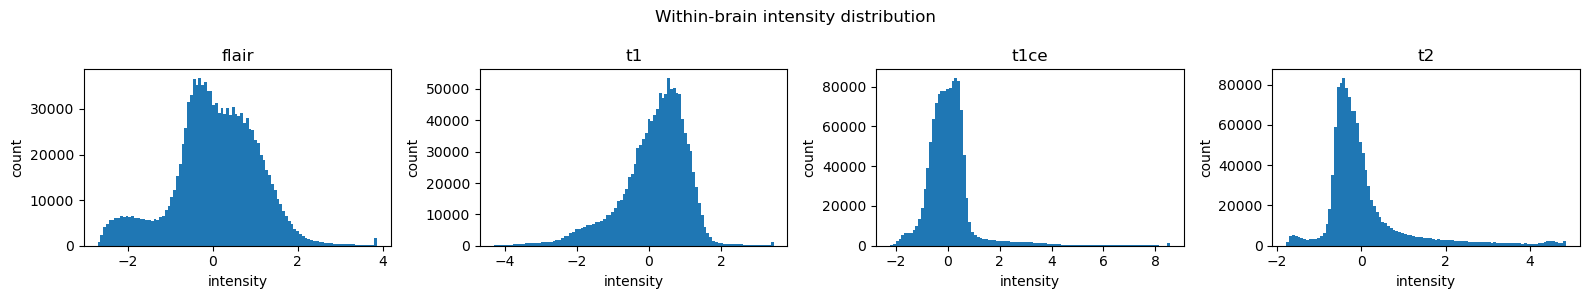

In [4]:
fig, axes = plt.subplots(1, C, figsize=(4 * C, 3))
axes = np.atleast_1d(axes)
for c in range(C):
    vals = img[..., c][mask] if mask is not None else img[..., c].ravel()
    axes[c].hist(vals, bins=100)
    axes[c].set_title(names[c] if c < len(names) else f'ch{c}')
    axes[c].set_xlabel('intensity'); axes[c].set_ylabel('count')
fig.suptitle('Within-brain intensity distribution' if mask is not None else 'Intensity distribution')
plt.tight_layout(); plt.show()

## Mid-slice montage (one panel per contrast)

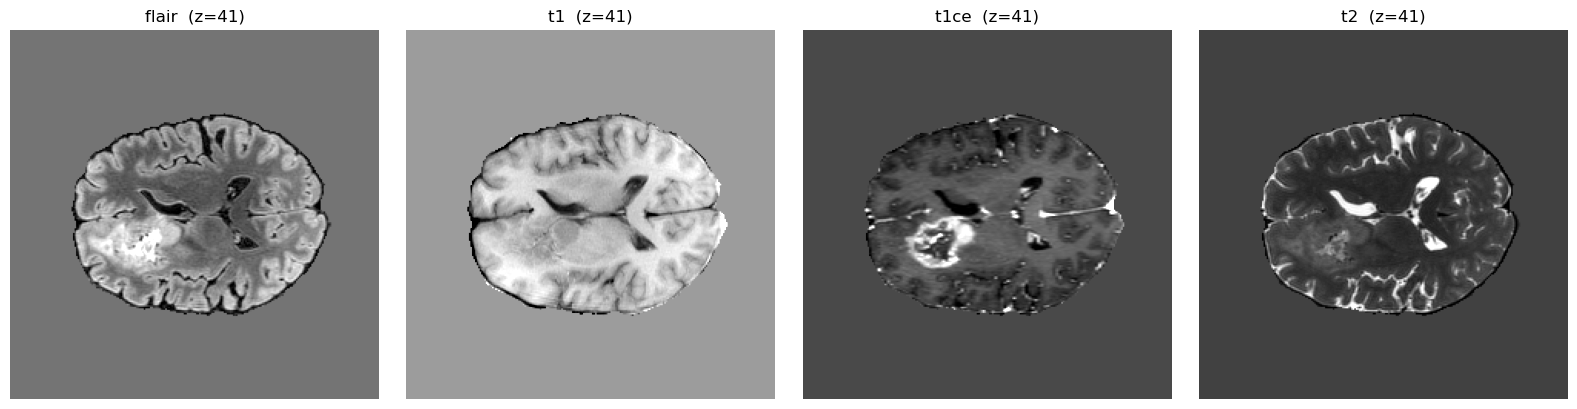

In [5]:
z = N // 2     # a central kept slice
fig, axes = plt.subplots(1, C, figsize=(4 * C, 4))
axes = np.atleast_1d(axes)
for c in range(C):
    sl = img[z, :, :, c]
    # scale display by within-brain range so contrast is visible (not background-dominated)
    if mask is not None and mask[z].any():
        bvals = sl[mask[z]]
        vmin, vmax = np.percentile(bvals, [1, 99])
    else:
        vmin, vmax = np.percentile(sl, [1, 99])
    axes[c].imshow(sl, cmap='gray', vmin=vmin, vmax=vmax)
    axes[c].set_title(f'{names[c] if c < len(names) else c}  (z={z})')
    axes[c].axis('off')
plt.tight_layout(); plt.show()

## Per-slice brain fraction

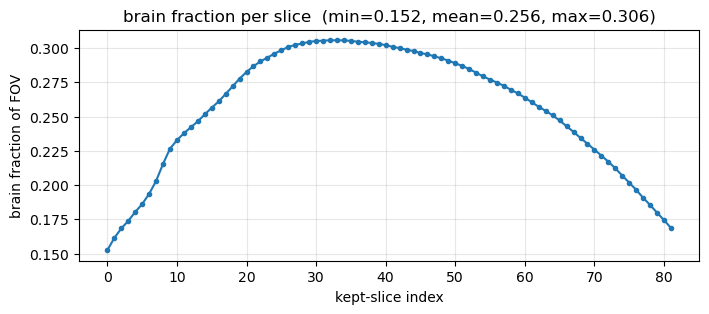

In [6]:
if mask is not None:
    frac = mask.reshape(N, -1).mean(1)
    plt.figure(figsize=(8, 3))
    plt.plot(frac, marker='.')
    plt.xlabel('kept-slice index'); plt.ylabel('brain fraction of FOV')
    plt.title(f'brain fraction per slice  (min={frac.min():.3f}, mean={frac.mean():.3f}, max={frac.max():.3f})')
    plt.grid(alpha=0.3); plt.show()
else:
    print('no mask -> brain fraction unavailable')